# Importing Libraries

Data Handling

In [1]:
import pandas as pd
import numpy as np

Data Visualization

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Preprocessing

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Model Training

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Model Evaluation

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Model Saving


In [6]:
import pickle

Ignore Warnings

In [7]:
import warnings
warnings.filterwarnings("ignore")

# Loading and Understanding the Data

Load and Show Data

In [8]:
df = pd.read_csv("data/customer_churn_data.csv")
df

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No


In [9]:
# Function to add blank lines between outputs for better readability
def addSpace():
    print("\n\n")

- First 5 Rows

In [10]:
print(df.head())
addSpace()

  customer_id  age  gender region  tenure_months  monthly_charges  \
0   CUST10001   23  Female   East             45            65.65   
1   CUST10002   66    Male   East             43           105.10   
2   CUST10003   59  Female   West             16            61.12   
3   CUST10004   45  Female   East             58            89.25   
4   CUST10005   45  Female  North             50            91.11   

   total_charges   contract_type internet_service tech_support  \
0        2659.64        Two year              DSL          Yes   
1        4357.87        One year      Fiber optic           No   
2        1074.50  Month-to-month              DSL           No   
3        4973.26        One year      Fiber optic          Yes   
4        4580.38  Month-to-month      Fiber optic          Yes   

  online_security paperless_billing    payment_method  num_support_calls  \
0             Yes                No  Electronic check                  1   
1             Yes               Yes 

- Last 5 Rows

In [11]:
print(df.tail())
addSpace()

     customer_id  age  gender region  tenure_months  monthly_charges  \
1215   CUST10722   76  Female  South             48            61.37   
1216   CUST11129   53    Male   East              9            86.36   
1217   CUST10400   37  Female  South             69            78.02   
1218   CUST10695   23    Male  South             56            84.87   
1219   CUST10110   62  Female   West             45            89.86   

      total_charges   contract_type internet_service tech_support  \
1215        2896.21  Month-to-month              DSL          Yes   
1216         716.92        One year      Fiber optic          Yes   
1217        5132.74        One year      Fiber optic           No   
1218        4533.03        One year      Fiber optic           No   
1219        3730.49        Two year      Fiber optic           No   

     online_security paperless_billing    payment_method  num_support_calls  \
1215             Yes               Yes  Electronic check                 

- Number of Rows and Columns

In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
addSpace()

Number of rows: 1220
Number of columns: 17





- Column Names

In [13]:
print(df.columns)
addSpace()

Index(['customer_id', 'age', 'gender', 'region', 'tenure_months',
       'monthly_charges', 'total_charges', 'contract_type', 'internet_service',
       'tech_support', 'online_security', 'paperless_billing',
       'payment_method', 'num_support_calls', 'late_payments_last_year',
       'avg_monthly_usage_gb', 'churn'],
      dtype='str')





- Data Types

In [14]:
print(df.dtypes)
addSpace()

customer_id                    str
age                          int64
gender                         str
region                         str
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type                  str
internet_service               str
tech_support                   str
online_security                str
paperless_billing              str
payment_method                 str
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                          str
dtype: object





- Dataset Information

In [15]:
print(df.info())
addSpace()

<class 'pandas.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1220 non-null   str    
 1   age                      1220 non-null   int64  
 2   gender                   1220 non-null   str    
 3   region                   1220 non-null   str    
 4   tenure_months            1220 non-null   int64  
 5   monthly_charges          1198 non-null   float64
 6   total_charges            1187 non-null   float64
 7   contract_type            1220 non-null   str    
 8   internet_service         1220 non-null   str    
 9   tech_support             1194 non-null   str    
 10  online_security          1199 non-null   str    
 11  paperless_billing        1220 non-null   str    
 12  payment_method           1200 non-null   str    
 13  num_support_calls        1220 non-null   int64  
 14  late_payments_last_year  1220 non-n

- Descriptive Statistics

In [16]:
print(df.describe())
addSpace()

               age  tenure_months  monthly_charges  total_charges  \
count  1220.000000    1220.000000      1198.000000    1187.000000   
mean     49.309016      36.956557        66.509474    2421.133437   
std      18.125678      20.512560        24.295211    1681.896803   
min      18.000000       1.000000        18.000000      12.600000   
25%      34.000000      19.000000        50.047500    1011.740000   
50%      49.500000      38.000000        69.020000    2120.450000   
75%      65.000000      55.000000        86.465000    3619.765000   
max      80.000000      72.000000       118.580000    7579.280000   

       num_support_calls  late_payments_last_year  avg_monthly_usage_gb  
count        1220.000000              1220.000000           1196.000000  
mean            1.759836                 1.143443            214.370569  
std             1.298902                 1.078501            143.970148  
min             0.000000                 0.000000              0.000000  
25%     

# Data Quality Checks

- Missing Values in Every Column

In [17]:
# Check the number of missing values in every column
missing_values = df.isnull().sum()

# Display the missing values
print(missing_values)

addSpace()

customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64





- Duplicate Records

In [18]:
# Check the number of duplicate records
duplicate_count = df.duplicated().sum()

# Display the number of duplicate records
print("Number of duplicate records:", duplicate_count)

addSpace()

Number of duplicate records: 20





- Unique Values in Categorical Columns

In [19]:
# Select categorical columns
categorical_columns = df.select_dtypes(include="object").columns

# Display unique values for each categorical column
for column in categorical_columns:
    print(f"\nUnique values in {column}:")
    print(df[column].unique())

addSpace()


Unique values in customer_id:
<ArrowStringArray>
['CUST10001', 'CUST10002', 'CUST10003', 'CUST10004', 'CUST10005', 'CUST10006',
 'CUST10007', 'CUST10008', 'CUST10009', 'CUST10010',
 ...
 'CUST11191', 'CUST11192', 'CUST11193', 'CUST11194', 'CUST11195', 'CUST11196',
 'CUST11197', 'CUST11198', 'CUST11199', 'CUST11200']
Length: 1200, dtype: str

Unique values in gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Unique values in region:
<ArrowStringArray>
['East', 'West', 'North', 'South']
Length: 4, dtype: str

Unique values in contract_type:
<ArrowStringArray>
['Two year', 'One year', 'Month-to-month']
Length: 3, dtype: str

Unique values in internet_service:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Unique values in tech_support:
<ArrowStringArray>
['Yes', 'No', 'No internet service', nan]
Length: 4, dtype: str

Unique values in online_security:
<ArrowStringArray>
['Yes', 'No', 'No internet service', nan]
Length: 4, dtype: str

Unique valu

- Class Distribution of the Churn Target

In [20]:
# Count the number of records in each Churn class
churn_distribution = df["churn"].value_counts()

# Display the class distribution
print("Class Distribution of Churn:")
print(churn_distribution)

addSpace()

Class Distribution of Churn:
churn
Yes    688
No     532
Name: count, dtype: int64





# Data Cleaning

In [21]:
df

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No


In [22]:
# check duplicate customers
df["customer_id"].duplicated().sum()

np.int64(20)

In [23]:
# remove duplicates based on 'customer_id'
df = df.drop_duplicates(subset="customer_id", keep="first")

In [24]:
# verify that there is no duplicate customer
df["customer_id"].duplicated().sum()

np.int64(0)

In [25]:
# check missing numeric values
missing_numeric = df.select_dtypes(include="number").isnull().sum()
missing_numeric[missing_numeric > 0]

monthly_charges         21
total_charges           33
avg_monthly_usage_gb    24
dtype: int64

In [26]:
# check percentage of missing numeric values
missing_percent = (df.select_dtypes(include="number").isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]

total_charges           2.75
avg_monthly_usage_gb    2.00
monthly_charges         1.75
dtype: float64

In [27]:
# fill the missing numeric values with median
numeric_cols = [
    "total_charges",
    "avg_monthly_usage_gb",
    "monthly_charges"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [28]:
# verify changes
df[numeric_cols].isnull().sum()

total_charges           0
avg_monthly_usage_gb    0
monthly_charges         0
dtype: int64

In [29]:
# find missing categorical values
categorical_columns = df.select_dtypes(include="object").columns
missing_categories = df[categorical_columns].isnull().sum()
missing_categories[missing_categories > 0]

tech_support       26
online_security    21
payment_method     19
dtype: int64

In [30]:
# count values in online_security
df["online_security"].value_counts(dropna=False)

online_security
No                     531
Yes                    455
No internet service    193
NaN                     21
Name: count, dtype: int64

In [31]:
# customers who have internet_service but do not have online_security (NaN)
df[df['online_security'].isna()]['internet_service'].value_counts()

internet_service
Fiber optic    13
DSL             6
No              2
Name: count, dtype: int64

In [32]:
# fill missing value with 'Unknown'
df['online_security'] = df['online_security'].fillna('Unknown')

In [33]:
# verify changes
df["online_security"].value_counts(dropna=False)

online_security
No                     531
Yes                    455
No internet service    193
Unknown                 21
Name: count, dtype: int64

In [34]:
# count values in tech_support       
df["tech_support"].value_counts(dropna=False)

tech_support
No                     570
Yes                    414
No internet service    190
NaN                     26
Name: count, dtype: int64

In [35]:
# check if customer has internet_service
df[df['tech_support'].isna()]['internet_service'].value_counts()

internet_service
Fiber optic    11
DSL            10
No              5
Name: count, dtype: int64

In [36]:
# customers with no internet_service are set to "No internet service"
df.loc[
    (df['internet_service'] == 'No') &
    (df['tech_support'].isna()),
    'tech_support'
] = 'No internet service'

In [37]:
# remaining will be set to "Unknown", since they have internet but do not have tech support (reason is unknown)
df['tech_support'] = df['tech_support'].fillna('Unknown')

In [38]:
# verify changes
df["tech_support"].value_counts(dropna=False)

tech_support
No                     570
Yes                    414
No internet service    195
Unknown                 21
Name: count, dtype: int64

In [39]:
# count values in payment_method       
df["payment_method"].value_counts(dropna=False)

payment_method
Electronic check    391
Bank transfer       280
Credit card         269
Mailed check        241
NaN                  19
Name: count, dtype: int64

In [40]:
# set missing value as "Unknown"
df['payment_method'] = df['payment_method'].fillna('Unknown')

In [41]:
# verify changes
df["payment_method"].value_counts(dropna=False)

payment_method
Electronic check    391
Bank transfer       280
Credit card         269
Mailed check        241
Unknown              19
Name: count, dtype: int64

In [42]:
# now, removing customer_id
df.drop('customer_id', axis=1, inplace=True)

In [43]:
# verify changes
df

,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,57,Female,West,16,71.37,1146.29,Month-to-month,Fiber optic,Unknown,No,Yes,Bank transfer,1,2,326.5,Yes
1196,62,Female,South,62,70.56,4341.44,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,2,0,138.2,Yes
1197,79,Male,North,71,72.85,4748.78,Two year,DSL,Yes,Yes,Yes,Credit card,3,2,97.5,No
1198,68,Male,North,55,93.70,5231.25,Month-to-month,Fiber optic,No,No,Yes,Mailed check,2,1,426.4,Yes


### Explaination: 
- Duplicate records are deleted, since the record is identical, it may impact on training/testing. That may lead to incorrect results.
- Based on customer_id we find the duplicate records, since the customer_id represents a unique customer.
    - For online_security, we check the customers with internet_service. Most of the customers have internet but do not have online security so we set as "Unknown" (we do not know why they did not have online security service inspite of having internet service and we cannot set it as "No")
  - Same logic is applied to tech_support.
  - For payment_method, we simply set the missing values as "Unknown", since there is no dependency for them.
- customer_id has nothing to do with our prediction, so we removed that column.

# Exploratory Data Analysis

- Churn Class Distribution

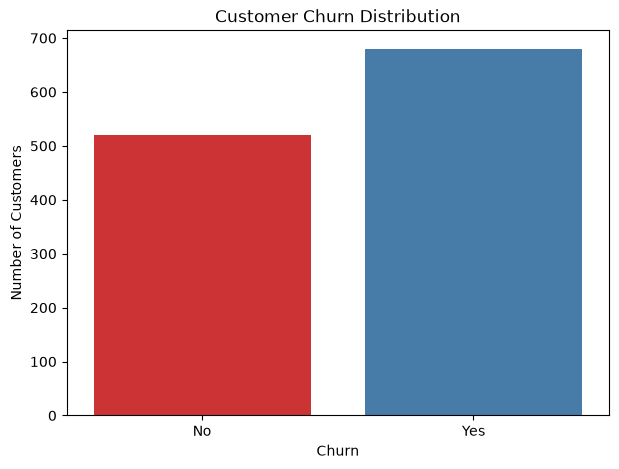

In [44]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="churn", hue="churn", palette="Set1", legend=False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

#### Observation: Around 500 customers churned, while approximately 700 customers did not churn. This shows that the dataset has more non-churned customers than churned customers, indicating a moderate class imbalance.


- Churn by Contract Type

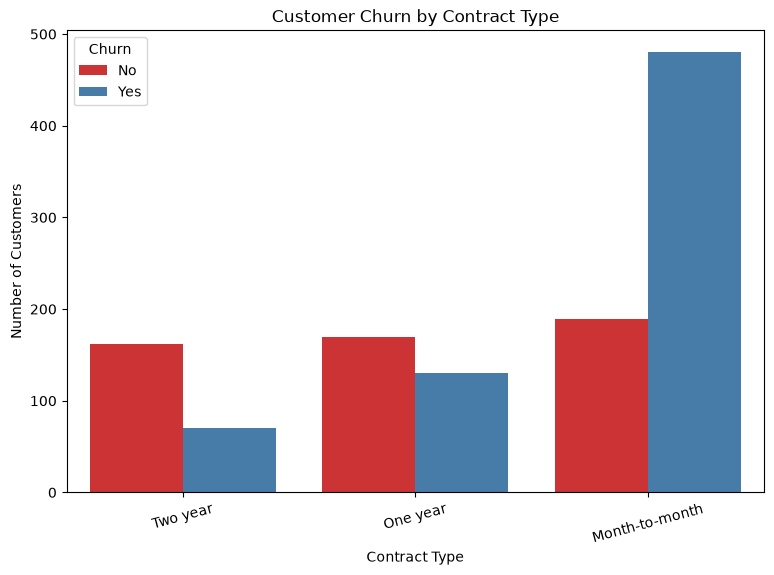

In [45]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x="contract_type", hue="churn", palette="Set1")
plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.legend(title="Churn")
plt.show()

#### Observation: Customers with month-to-month contracts show higher churn compared with customers with one year and two year contracts

- Churn by Internet Service

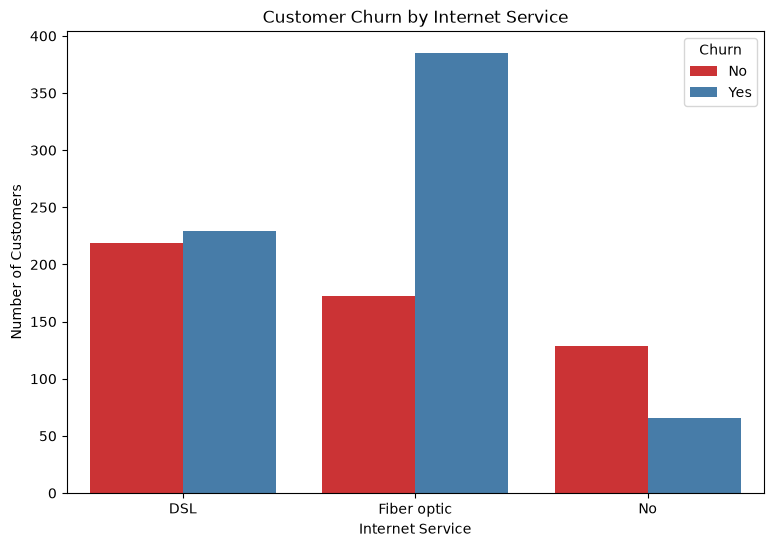

In [46]:
plt.figure(figsize=(9, 6))
sns.countplot(data=df, x="internet_service", hue="churn", palette="Set1")
plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

#### Observation: Fiber optic customers tend to have higher churn than DSL and customers without internet service.

- Monthly Charges Distribution

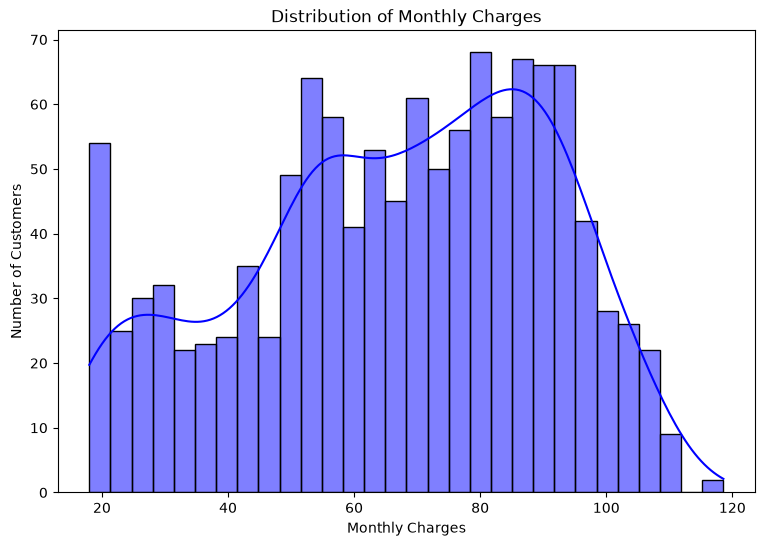

In [47]:
plt.figure(figsize=(9, 6))
sns.histplot(data=df, x="monthly_charges", bins=30, kde=True, color="blue")
plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

#### Observation: Customers with higher monthly charges are more likely to churn, suggesting pricing may influence customer retention.

- Tenure Distribution

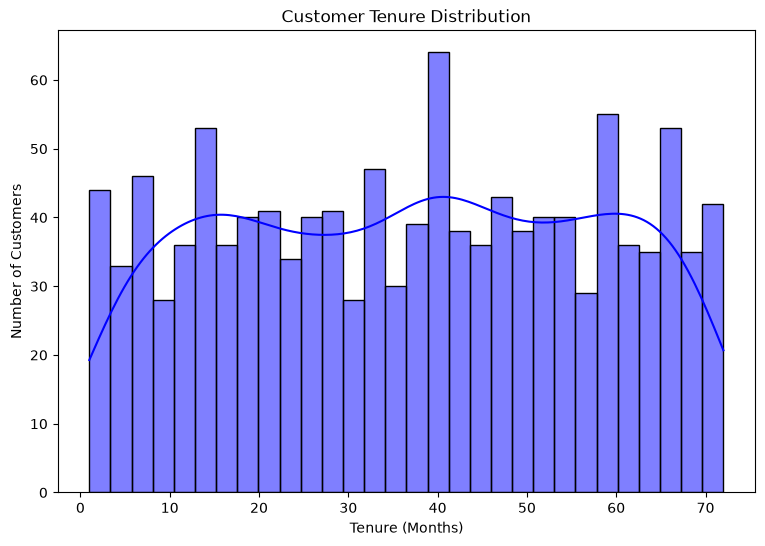

In [48]:
plt.figure(figsize=(9, 6))
sns.histplot(data=df, x="tenure_months", bins=30, kde=True, color="blue")
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()


#### Observation: Customers with shorter tenure are more likely to churn, while long-term customers generally show better retention.

- Additional Visualization: Churn by Payment Method

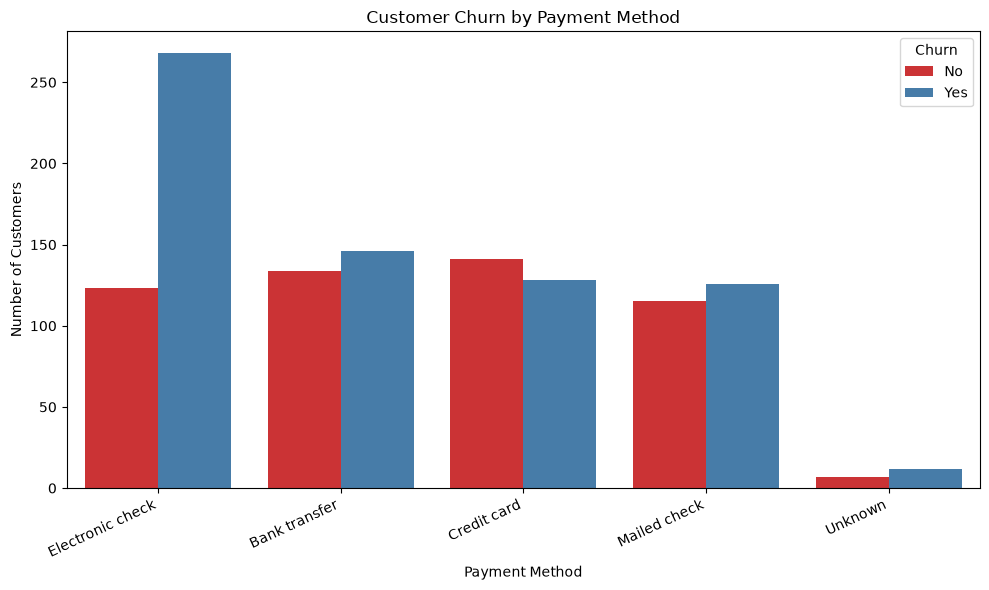

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="payment_method", hue="churn", palette="Set1")
plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

#### Observation: Customers using electronic check generally show higher churn compared with customers using other payment methods

# Prepare Feature and Target

In [50]:
# Target variable
y = df["churn"]

# Input features, dropping churn
X = df.drop("churn", axis=1)

print("Features (X):")
print(X.head())
addSpace()

print("Target (y):")
print(y.head())
addSpace()


Features (X):
   age  gender region  tenure_months  monthly_charges  total_charges  \
0   23  Female   East             45            65.65        2659.64   
1   66    Male   East             43           105.10        4357.87   
2   59  Female   West             16            61.12        1074.50   
3   45  Female   East             58            89.25        4973.26   
4   45  Female  North             50            91.11        4580.38   

    contract_type internet_service tech_support online_security  \
0        Two year              DSL          Yes             Yes   
1        One year      Fiber optic           No             Yes   
2  Month-to-month              DSL           No             Yes   
3        One year      Fiber optic          Yes             Yes   
4  Month-to-month      Fiber optic          Yes             Yes   

  paperless_billing    payment_method  num_support_calls  \
0                No  Electronic check                  1   
1               Yes  Electroni

In [51]:
# Since churn contains Yes/No, convert it into numerical values for machine learning: 
# Convert target variable to 0 and 1
y = df["churn"].map({"No": 0, "Yes": 1})

# Input features
X = df.drop("churn", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
addSpace()


X shape: (1200, 15)
y shape: (1200,)





In [52]:
# Identify numeric columns
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numeric columns:")
print(list(numeric_columns))

print("Categorical columns:")
print(list(categorical_columns))
addSpace()


Numeric columns:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb']
Categorical columns:
['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method']





# Train-Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
addSpace()


Training data: (960, 15)
Testing data: (240, 15)





# Preprocessing

In [54]:
numeric_features = [
    "age",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "num_support_calls",
    "late_payments_last_year",
    "avg_monthly_usage_gb"
]

categorical_features = [
    "gender",
    "region",
    "contract_type",
    "internet_service",
    "tech_support",
    "online_security",
    "paperless_billing",
    "payment_method"
]

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns



print("Preprocessing pipeline created successfully.")



Preprocessing pipeline created successfully.


# Model Training

In [55]:
# Logistic Regressioin Pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Train
logistic_model.fit(X_train, y_train)

#Predict
y_pred_logistic = logistic_model.predict(X_test)


In [56]:
# Random Forest Pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Test
y_pred_rf = rf_model.predict(X_test)


In [57]:
# Comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.762500,0.768707,0.830882,0.798587
1,Random Forest,0.695833,0.711409,0.779412,0.743860


# Model Evaluation

- Logistic Regression

In [58]:
# Predictions
y_pred_logistic = logistic_model.predict(X_test)

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

# Precision
print("Precision:", precision_score(y_test, y_pred_logistic))

# Recall
print("Recall:", recall_score(y_test, y_pred_logistic))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred_logistic))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

LOGISTIC REGRESSION
Accuracy: 0.7625
Precision: 0.7687074829931972
Recall: 0.8308823529411765
F1 Score: 0.7985865724381626

Confusion Matrix:
[[ 70  34]
 [ 23 113]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       104
           1       0.77      0.83      0.80       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240



- Random Forest

In [59]:
# Predictions
y_pred_rf = rf_model.predict(X_test)

print("\n" + "=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Precision
print("Precision:", precision_score(y_test, y_pred_rf))

# Recall
print("Recall:", recall_score(y_test, y_pred_rf))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))




RANDOM FOREST
Accuracy: 0.6958333333333333
Precision: 0.7114093959731543
Recall: 0.7794117647058824
F1 Score: 0.743859649122807

Confusion Matrix:
[[ 61  43]
 [ 30 106]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.59      0.63       104
           1       0.71      0.78      0.74       136

    accuracy                           0.70       240
   macro avg       0.69      0.68      0.68       240
weighted avg       0.69      0.70      0.69       240



#### Comparison Table

In [60]:
comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf)
    ]
})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.762500,0.768707,0.830882,0.798587
1,Random Forest,0.695833,0.711409,0.779412,0.743860


# Selecting the Final Model

In [61]:
print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

print("\nRandom Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("\n")

Logistic Regression
Accuracy : 0.7625
Precision: 0.7687074829931972
Recall   : 0.8308823529411765
F1 Score : 0.7985865724381626

Random Forest
Accuracy : 0.6958333333333333
Precision: 0.7114093959731543
Recall   : 0.7794117647058824
F1 Score : 0.743859649122807




#### Explanation: 
Logistic Regression performs better than Random Forest on all four evaluation metrics. For a customer churn prediction problem, recall is particularly important. A false negative means that a customer who actually churns is predicted as someone who will stay. Logistic Regression achieves a recall of 83.09%, meaning it identifies a larger proportion of the actual churners than Random Forest. It also has the higher F1 Score (79.86%), which indicates a better balance between precision and recall. Therefore, Logistic Regression should be selected as the final model.

# Saving the Final Model

In [62]:
# Create pipeline
churn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train pipeline
churn_pipeline.fit(X_train, y_train)

# Verify Pipeline
y_pred = churn_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.7625
Precision: 0.7687074829931972
Recall: 0.8308823529411765
F1 Score: 0.7985865724381626


In [63]:
# Save .pkl file
with open("models/churn_pipeline.pkl", "wb") as file:
    pickle.dump(churn_pipeline, file)

print("models/churn_pipeline.pkl saved successfully.")

models/churn_pipeline.pkl saved successfully.


# Reloading and Testing the Saved Model

In [64]:
# Load the saved pipeline

with open("models/churn_pipeline.pkl", "rb") as file:
    loaded_pipeline = pickle.load(file)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [65]:
# Dummy customer for testing
mock_customer = pd.DataFrame([{
    "age": 35,
    "tenure_months": 12,
    "monthly_charges": 75.50,
    "total_charges": 906.00,
    "num_support_calls": 3,
    "late_payments_last_year": 1,
    "avg_monthly_usage_gb": 45.0,
    
    "gender": "Female",
    "region": "South",
    "contract_type": "Month-to-month",
    "internet_service": "Fiber optic",
    "tech_support": "No",
    "online_security": "No",
    "paperless_billing": "Yes",
    "payment_method": "Electronic check"
}])

# Test the prediction
prediction = loaded_pipeline.predict(mock_customer)

# 1 means churn and 0 means no churn
print("Prediction:", prediction[0])


Prediction: 1
